In [101]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [102]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from imblearn.metrics import specificity_score

In [60]:
data_location = '../data/processed/df.csv'

In [61]:
df = pd.read_csv(data_location)

In [62]:
columns_to_drop = ['Дата ликвидации', 'ogrn_str', 'Год',
    'Регион', 'Выручка, RUB', 'Форма собственности', 'Важная информация', 'Возраст компании, лет', 'region_code', 'Вид деятельности/отрасль', 'Среднесписочная численность работников', 'Unnamed: 0', 'Коэффициент покрытия процентов по EBIT, %']
model_df = df.set_index('Регистрационный номер').drop(columns=columns_to_drop)

for column in model_df.loc[:, 'Коэффициент быстрой ликвидности, %':'Соотношение совокупного долга к капиталу, %'].columns.to_list():
    low, high = model_df.loc[:, column].quantile([0.05, 0.95])
    model_df.loc[:, column] = model_df.loc[:, column].clip(lower=low, upper=high)

In [63]:
X = model_df.drop(columns=['next_year_liqudation'])
y = model_df['next_year_liqudation']

In [64]:
companies = model_df.index.unique()

train_comp, test_comp = train_test_split(
    companies, test_size=0.2, stratify=y.groupby(level=0).max(), random_state=13
)

In [65]:
X_train = X.loc[train_comp]
X_test  = X.loc[test_comp]
y_train = y.loc[train_comp]
y_test  = y.loc[test_comp]

In [84]:
cat_features=[]

model = CatBoostClassifier(
    iterations=2000,
    depth=8,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='Recall',
    class_weights=[1, 30],
    random_state=13,
    verbose=200,
    cat_features=cat_features,
    od_wait=200,
    od_type='Iter'
)

In [85]:
model.fit(
    Pool(X_train, y_train, cat_features=cat_features),
    eval_set=Pool(X_test, y_test, cat_features=cat_features)
)

0:	learn: 0.9226328	test: 0.8808290	best: 0.8808290 (0)	total: 15.6ms	remaining: 31.2s
200:	learn: 0.9942263	test: 0.9481865	best: 0.9533679 (148)	total: 1.17s	remaining: 10.5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9533678756
bestIteration = 148

Shrink model to first 149 iterations.


In [86]:
preds = model.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, preds))

AUC: 0.9808993422189997


In [87]:
PROBABILITY_THRESHOLD = 0.4

In [105]:
y_pred_class = (preds >= PROBABILITY_THRESHOLD).astype(int)

precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
specf = specificity_score(y_test, y_pred_class)
acc = accuracy_score(y_test, (preds > PROBABILITY_THRESHOLD).astype(int))

print(f"Precision (точность) для банкротов: {precision:.3f}")
print(f"Recall (полнота) для банкротов: {recall:.3f}")
print(f"F1-score для банкротов: {f1:.3f}")
print(f"Accuracy: {acc:.3f}")
print(f"Specificity: {specf:.3f}")


Precision (точность) для банкротов: 0.311
Recall (полнота) для банкротов: 0.959
F1-score для банкротов: 0.470
Accuracy: 0.935
Specificity: 0.934


In [89]:
y_pred_class = (preds >= PROBABILITY_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_class)

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

Confusion Matrix:
[[5765  409]
 [   8  185]]

True Negatives:  5765
False Positives: 409
False Negatives: 8
True Positives:  185


In [ ]:
company_max_pred = pd.Series(preds, index=X_test.index).groupby(level=0).max()
company_any_bankruptcy = y_test.groupby(level=0).max()

company_last_pred = pd.Series(preds, index=X_test.index).groupby(level=0).last()
company_last_true = y_test.groupby(level=0).last()

y_pred_company_max = (company_max_pred >= PROBABILITY_THRESHOLD).astype(int)
print("=== Метрики на уровне компаний (max probability) ===")
print(f"Precision: {precision_score(company_any_bankruptcy, y_pred_company_max):.3f}")
print(f"Recall: {recall_score(company_any_bankruptcy, y_pred_company_max):.3f}")
print(f"F1: {f1_score(company_any_bankruptcy, y_pred_company_max):.3f}")
print(f"Specifity: {specificity_score(company_any_bankruptcy, y_pred_company_max):.3f}")

y_pred_company_last = (company_last_pred >= PROBABILITY_THRESHOLD).astype(int)
print("\n=== Метрики на уровне компаний (last year) ===")
print(f"Precision: {precision_score(company_last_true, y_pred_company_last):.3f}")
print(f"Recall: {recall_score(company_last_true, y_pred_company_last):.3f}")
print(f"F1: {f1_score(company_last_true, y_pred_company_last):.3f}")
print(f"specificity: {specificity_score(company_last_true, y_pred_company_last):.3f}")

=== Метрики на уровне компаний (max probability) ===
Precision: 0.633
Recall: 0.964
F1: 0.764
Specifity: 0.923

=== Метрики на уровне компаний (last year) ===
Precision: 0.743
Recall: 0.959
F1: 0.837
Specifity: 0.954


In [96]:
bankrupt_companies = y_test[y_test == 1].index.unique()

early_warnings = []

for company in bankrupt_companies:
    company_mask = X_test.index.get_level_values(0) == company
    company_preds = preds[company_mask]
    company_years = X_test[company_mask].index
    
    high_risk_years = np.where(company_preds >= PROBABILITY_THRESHOLD)[0]
    
    if len(high_risk_years) > 0:
        first_warning_idx = high_risk_years[0]
        years_before = len(company_preds) - first_warning_idx - 1
        early_warnings.append(years_before)
    else:
        early_warnings.append(0)

print("=== Early Warning Analysis ===")
print(f"Среднее за сколько лет модель видит риск (prob>{PROBABILITY_THRESHOLD}): {np.mean(early_warnings):.1f} лет")
print(f"Максимум за сколько лет увидела: {np.max(early_warnings)} лет")
print("\nРаспределение:")
for years in range(5):
    count = sum(1 for x in early_warnings if x == years)
    print(f"  За {years+1} год до банкротства: {count} компаний")

=== Early Warning Analysis ===
Среднее за сколько лет модель видит риск (prob>0.4): 1.3 лет
Максимум за сколько лет увидела: 4 лет

Распределение:
  За 1 год до банкротства: 68 компаний
  За 2 год до банкротства: 49 компаний
  За 3 год до банкротства: 40 компаний
  За 4 год до банкротства: 27 компаний
  За 5 год до банкротства: 9 компаний


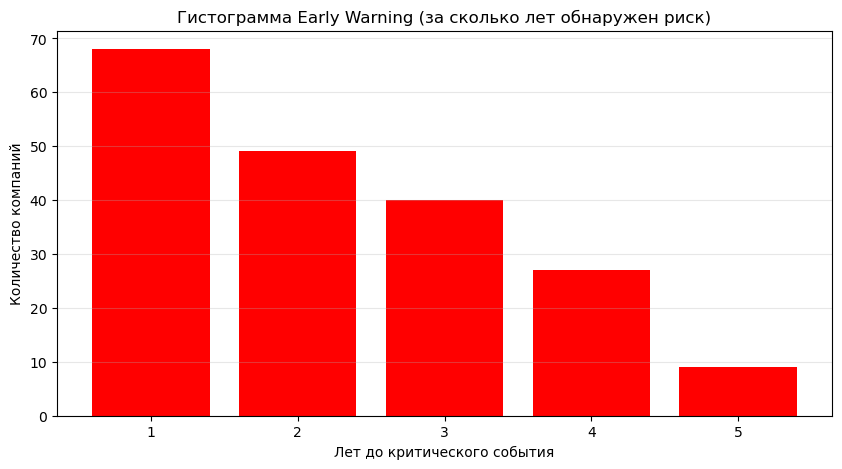

In [99]:
early_warnings_1based = [x + 1 for x in early_warnings]

plt.figure(figsize=(10, 5))
plt.hist(
    early_warnings_1based,
    bins=range(1, max(early_warnings_1based) + 2),
    align='left',
    rwidth=0.8,
    color='red'
)
plt.title('Гистограмма Early Warning (за сколько лет обнаружен риск)')
plt.xlabel('Лет до критического события')
plt.ylabel('Количество компаний')
plt.xticks(range(1, max(early_warnings_1based) + 1))
plt.grid(axis='y', alpha=0.3)
plt.show()


In [92]:
company_max_pred = pd.Series(preds, index=X_test.index).groupby(level=0).max()
company_any_bankruptcy = y_test.groupby(level=0).max()

y_pred_company = (company_max_pred >= PROBABILITY_THRESHOLD).astype(int)

cm = confusion_matrix(company_any_bankruptcy, y_pred_company)
print("\n=== Confusion Matrix (на уровне компаний) ===")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]} (здоровые компании, правильно классифицированы)")
print(f"False Positives: {cm[0,1]} (здоровые, но модель дала false alarm)")
print(f"False Negatives: {cm[1,0]} (банкроты, которых пропустили)")
print(f"True Positives:  {cm[1,1]} (банкроты, которых нашли)")


=== Confusion Matrix (на уровне компаний) ===
[[1289  108]
 [   7  186]]

True Negatives:  1289 (здоровые компании, правильно классифицированы)
False Positives: 108 (здоровые, но модель дала false alarm)
False Negatives: 7 (банкроты, которых пропустили)
True Positives:  186 (банкроты, которых нашли)


In [ ]:
bankrupt_companies = y_test[y_test == 1].index.unique()

sample_bankrupts = np.random.choice(bankrupt_companies, 3, replace=False)

for company in sample_bankrupts:
    company_data = pd.DataFrame({
        'true': y_test.loc[company],
        'pred': preds[X_test.index.get_level_values(0) == company]
    })
    
    print(f"\n=== Компания {company} ===")
    print(company_data)
    print(f"Динамика вероятности: {company_data['pred'].values}")


=== Компания 1023301463250.0 ===
                       true      pred
Регистрационный номер                
1.023301e+12              0  0.005381
1.023301e+12              0  0.009517
1.023301e+12              0  0.008272
1.023301e+12              0  0.001824
1.023301e+12              1  0.053855
Динамика вероятности: [0.00538148 0.00951683 0.00827172 0.0018243  0.0538551 ]

=== Компания 1087609002360.0 ===
                       true      pred
Регистрационный номер                
1.087609e+12              0  0.000259
1.087609e+12              0  0.018827
1.087609e+12              0  0.336080
1.087609e+12              0  0.976963
1.087609e+12              1  0.904875
Динамика вероятности: [2.58622947e-04 1.88273692e-02 3.36080294e-01 9.76963319e-01
 9.04874635e-01]

=== Компания 1026102579975.0 ===
                       true      pred
Регистрационный номер                
1.026103e+12              0  0.000336
1.026103e+12              0  0.051658
1.026103e+12              0  0.0070

In [76]:
precisions, recalls, thresholds = precision_recall_curve(y_test, preds)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог: {best_threshold}")
print(f"F1 на этом пороге: {f1_scores[best_idx]}")

Оптимальный порог: 0.7763887891406108
F1 на этом пороге: 0.6885245901639345


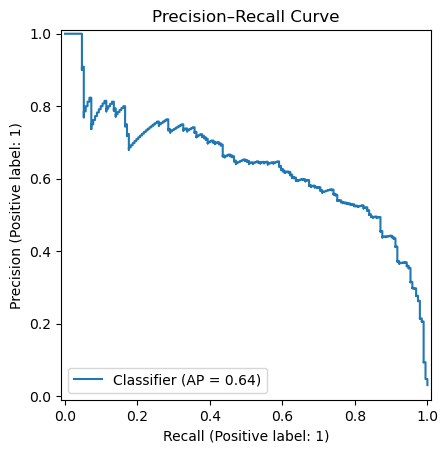

In [93]:
y_proba = model.predict_proba(X_test)[:, 1]

disp = PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision–Recall Curve")
plt.show()

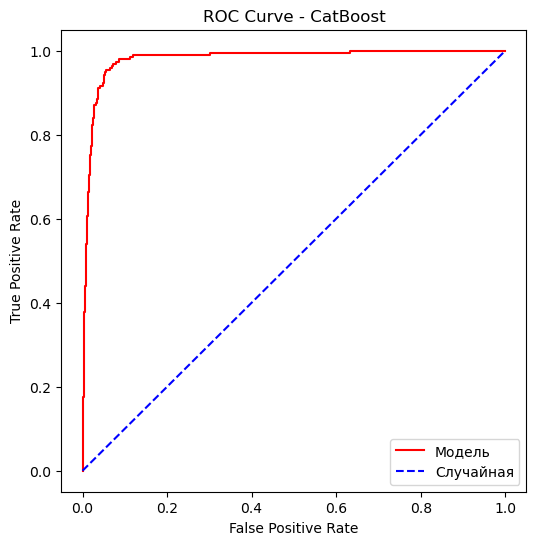

In [107]:
fpr, tpr, _ = roc_curve(y_test, preds)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='red', label='Модель')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Случайная')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.show()


In [79]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []
y_max = y.groupby(level=0).max()

for train_idx, test_idx in skf.split(companies, y_max.loc[companies]):
    train_comp = companies[train_idx]
    test_comp  = companies[test_idx]
    
    X_train_cv = X.loc[train_comp]
    X_test_cv  = X.loc[test_comp]
    y_train_cv = y.loc[train_comp]
    y_test_cv  = y.loc[test_comp]
    
    model = model
    
    train_pool = Pool(X_train_cv, y_train_cv, cat_features=cat_features)
    test_pool  = Pool(X_test_cv,  y_test_cv,  cat_features=cat_features)

    model.fit(train_pool, eval_set=test_pool)
    
    preds_cv = model.predict_proba(X_test_cv)[:, 1]
    aucs.append(roc_auc_score(y_test_cv, preds_cv))

print("CV AUC scores:", aucs)
print("Mean AUC:", np.mean(aucs))

0:	test: 0.9572288	best: 0.9572288 (0)	total: 5.9ms	remaining: 11.8s
200:	test: 0.9786314	best: 0.9786406 (197)	total: 1.23s	remaining: 11s
400:	test: 0.9787636	best: 0.9789983 (296)	total: 2.34s	remaining: 9.32s
600:	test: 0.9792254	best: 0.9792376 (595)	total: 3.4s	remaining: 7.91s
800:	test: 0.9792697	best: 0.9794295 (664)	total: 4.5s	remaining: 6.73s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9794295281
bestIteration = 664

Shrink model to first 665 iterations.
0:	test: 0.9509906	best: 0.9509906 (0)	total: 6.98ms	remaining: 13.9s
200:	test: 0.9727902	best: 0.9727902 (200)	total: 1.07s	remaining: 9.63s
400:	test: 0.9725365	best: 0.9728865 (213)	total: 2.15s	remaining: 8.57s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9728865295
bestIteration = 213

Shrink model to first 214 iterations.
0:	test: 0.9550928	best: 0.9550928 (0)	total: 5.99ms	remaining: 12s
200:	test: 0.9764712	best: 0.9766666 (146)	total: 1.07s	remaining: 9.62s
400:	tes

                                              feature  importance
9         Соотношение совокупного долга к капиталу, %   14.771662
5    Оборачиваемость кредиторской задолженности, разы   13.716558
13                            Ключевая_ставка_средняя   10.077407
11                           USD_RUB_средневзвешенный    7.531576
6                     Рентабельность активов (ROA), %    6.318139
2   Коэффициент оборачиваемости совокупных активов, %    6.005506
12             Индекс_предпринимательской_уверенности    5.850505
0                  Коэффициент быстрой ликвидности, %    5.462551
1   Коэффициент обеспеченности собственными оборот...    5.335953
3                  Коэффициент текущей ликвидности, %    5.310668


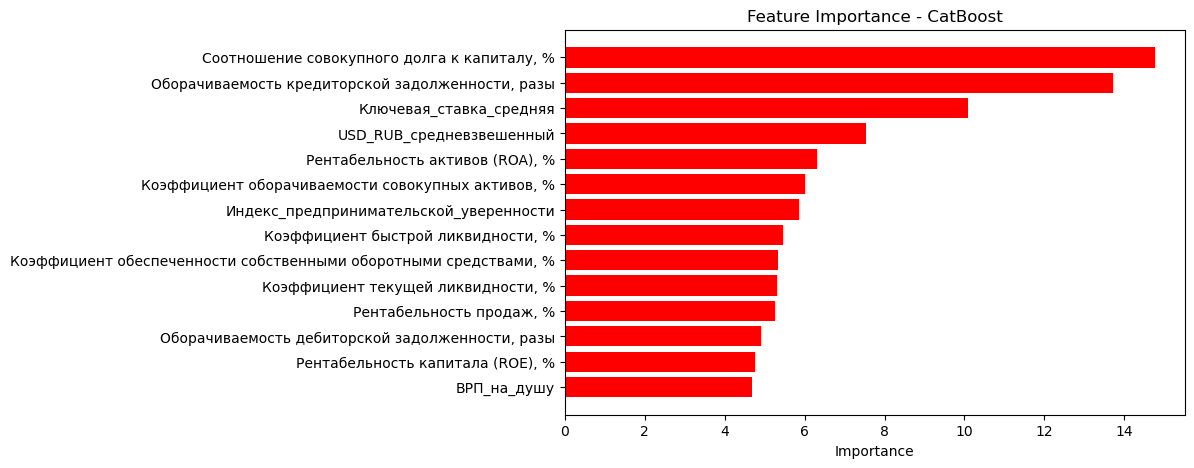

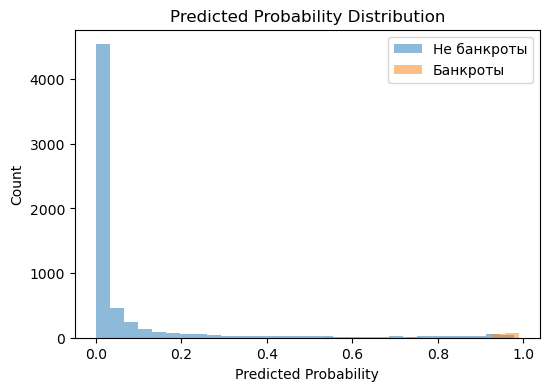

In [100]:
feature_importances = model.get_feature_importance(Pool(X_train, label=y_train, cat_features=cat_features))
feat_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

print(feat_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(feat_df['feature'], feat_df['importance'], color='red')
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance - CatBoost")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(preds[y_test==0], bins=30, alpha=0.5, label='Не банкроты')
plt.hist(preds[y_test==1], bins=30, alpha=0.5, label='Банкроты')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution')
plt.legend()
plt.show()


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [ ]:
#=================================================================================
# 10. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
#=================================================================================

print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1")
print("=" * 80)

# ROC-AUC
auc_score = roc_auc_score(y_test, y_test_pred1)
gini = 2 * auc_score - 1

print(f"AUC-ROC: {auc_score:.4f}")
print(f"Gini коэффициент: {gini:.4f}")

# KS-статистика
def ks_statistic(y_true, y_test_pred1):
    """Вычисление KS-статистики"""
    fpr, tpr, thresholds = roc_curve(y_true, y_test_pred1)
    ks = np.max(tpr - fpr)
    ks_threshold = thresholds[np.argmax(tpr - fpr)]
    return ks, ks_threshold

ks_stat, ks_thresh = ks_statistic(y_test, y_test_pred1)
print(f"KS-статистика: {ks_stat:.4f}")
print(f"Порог для KS: {ks_thresh:.4f}")

# Матрица ошибок с оптимальным порогом (по KS)
y_pred_ks = (y_test_pred1 >= ks_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_ks)

print("\nМатрица ошибок (порог = KS):")
print(cm)

# Детальные метрики
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")


МЕТРИКИ КАЧЕСТВА МОДЕЛИ 1
AUC-ROC: 0.9368
Gini коэффициент: 0.8735
KS-статистика: 0.7658
Порог для KS: 0.0327

Матрица ошибок (порог = KS):
[[5266  939]
 [  16  177]]

Accuracy: 0.8507
Precision: 0.1586
Recall (Sensitivity): 0.9171
Specificity: 0.8487
F1-Score: 0.2704


In [81]:
print(confusion_matrix(y_test, y_pred_class))

[[5996  178]
 [  26  167]]


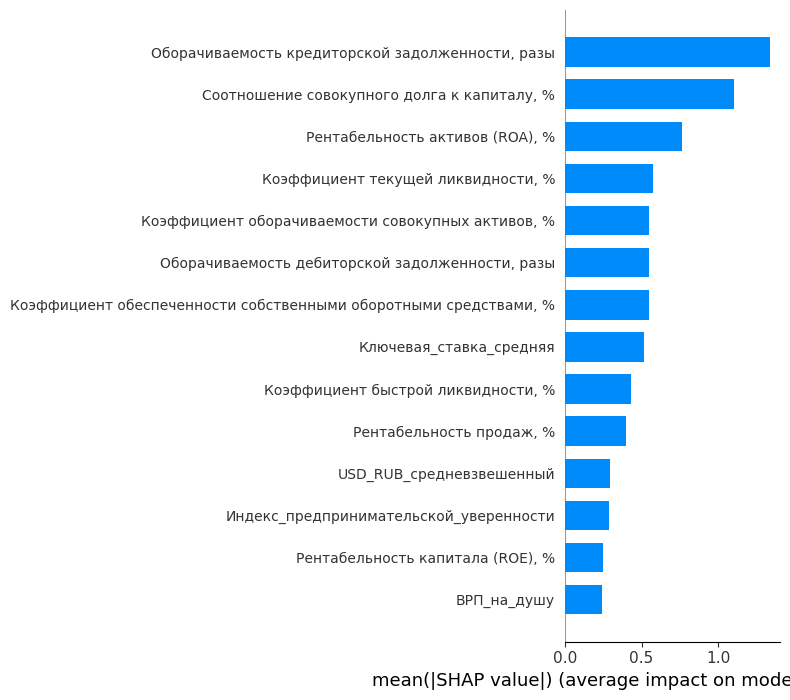

In [82]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

plt.gca().tick_params(axis='y', labelsize=10)  # размер шрифта по оси Y
plt.tight_layout()
plt.show()

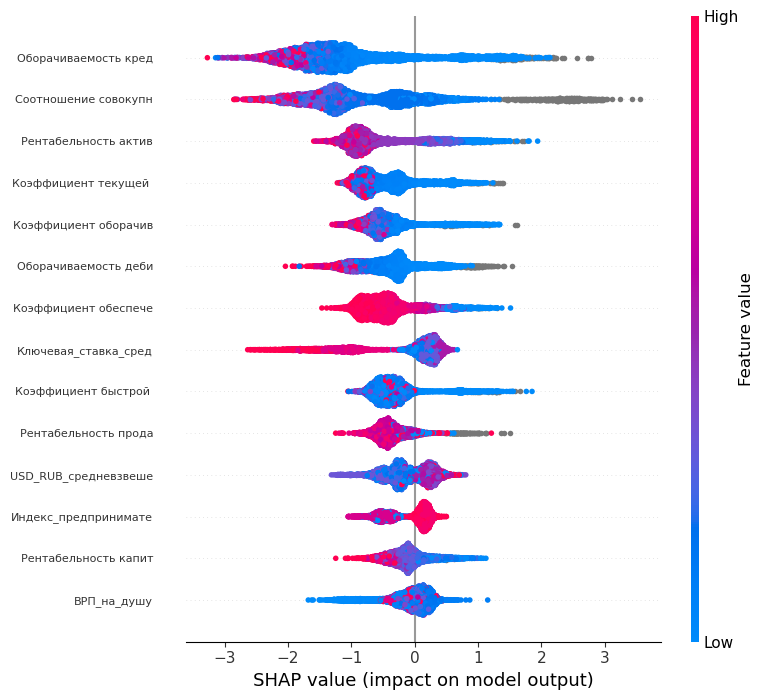

In [ ]:
X_test_short = X_test.copy()
X_test_short.columns = [c[:20] for c in X_test_short.columns]  # первые 20 символов

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test_short, show=False)
plt.gca().tick_params(axis='y', labelsize=8)  # уменьшенный шрифт
plt.tight_layout()
plt.show()
